# 1. The raw data

The COMSOL ensembles: each row is one **disorder realization** — one random
placement of trapped charges at the Si/SiO2 interface, solved for the resulting
double-quantum-dot parameters.

Two interface charge densities are shipped:

| dataset | density | realizations |
|---|---|---|
| `rho1e10` | 1e10 cm^-2 | 449 |
| `rho5e9`  | 5e9 cm^-2  | 500 |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # so `import chargetwin` works from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import chargetwin as ct

In [2]:
for name, ds in ct.DATASETS.items():
    print(f"{name:10s}  rho = {ds.density:12s}  {ds.description}")

rho1e10     rho = 1e10 cm^-2    449 disorder realizations, after virtual-gate tuning.
rho5e9      rho = 5e9 cm^-2     500 disorder realizations, after virtual-gate tuning.


## Which parameters can I ask for?

`load_dataset` converts the raw COMSOL output into physical units and builds the
derived quantities (dot sizes from the confinement curvatures, sums and
differences between the left and right dot).

In [3]:
pd.DataFrame(ct.PARAMETERS).T[["unit", "desc"]]

,unit,desc
d,nm,Inter-dot distance
tcs,ueV,Tunnel coupling
Lxavg,nm,Mean dot size along x
dLx,nm,Dot-size asymmetry along x
Lyavg,nm,Mean dot size along y
dLy,nm,Dot-size asymmetry along y
Favg,MV/m,Mean vertical electric field
dF,MV/m,Vertical-field asymmetry
eps,meV,Detuning at the tuned working point
Eavgs,meV,Mean orbital energy


## 2. Pick the parameters you care about

`ct.FIG5_PARAMETERS` is the set used in the paper. Swap in anything from the
table above — everything downstream (models, plots, metrics) follows your choice.

In [4]:
PARAMS = ct.FIG5_PARAMETERS  # ["d", "tcs", "Lxavg", "dLx", "Favg", "dF", "eps"]
DATASET = "rho1e10"

raw = ct.load_dataset(DATASET, PARAMS)
print(f"{len(raw)} realizations x {raw.shape[1]} parameters")
raw.head()

449 realizations x 7 parameters


,d,tcs,Lxavg,dLx,Favg,dF,eps
0,81.245489,142.466320,24.739962,0.119142,5.160946,0.008990,-1.750351
1,99.542310,32.873986,22.926281,-0.733889,5.184287,0.014087,1.032020
2,79.225676,159.683528,23.846480,0.356146,5.175409,0.000461,0.421171
3,82.398414,132.100685,23.779446,-0.086552,5.179389,-0.002844,0.042630
4,80.826418,150.729692,25.780690,-1.868479,5.151122,0.021582,2.171252


In [5]:
raw.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
d,90.510369,8.726075,63.907212,117.278228
tcs,86.591963,51.951730,2.791010,287.993594
Lxavg,23.803020,0.790886,21.873646,26.395813
dLx,0.014064,0.792246,-3.385191,2.256458
Favg,5.173095,0.010845,5.129542,5.195961
dF,-0.000003,0.012155,-0.031648,0.040477
eps,-0.015317,1.546122,-4.517356,3.965949


## Marginals

Each parameter fluctuates by a few percent to a few tens of percent around its
design value. `tcs` (tunnel coupling) is the outlier: it varies by nearly an
order of magnitude across nominally identical devices.

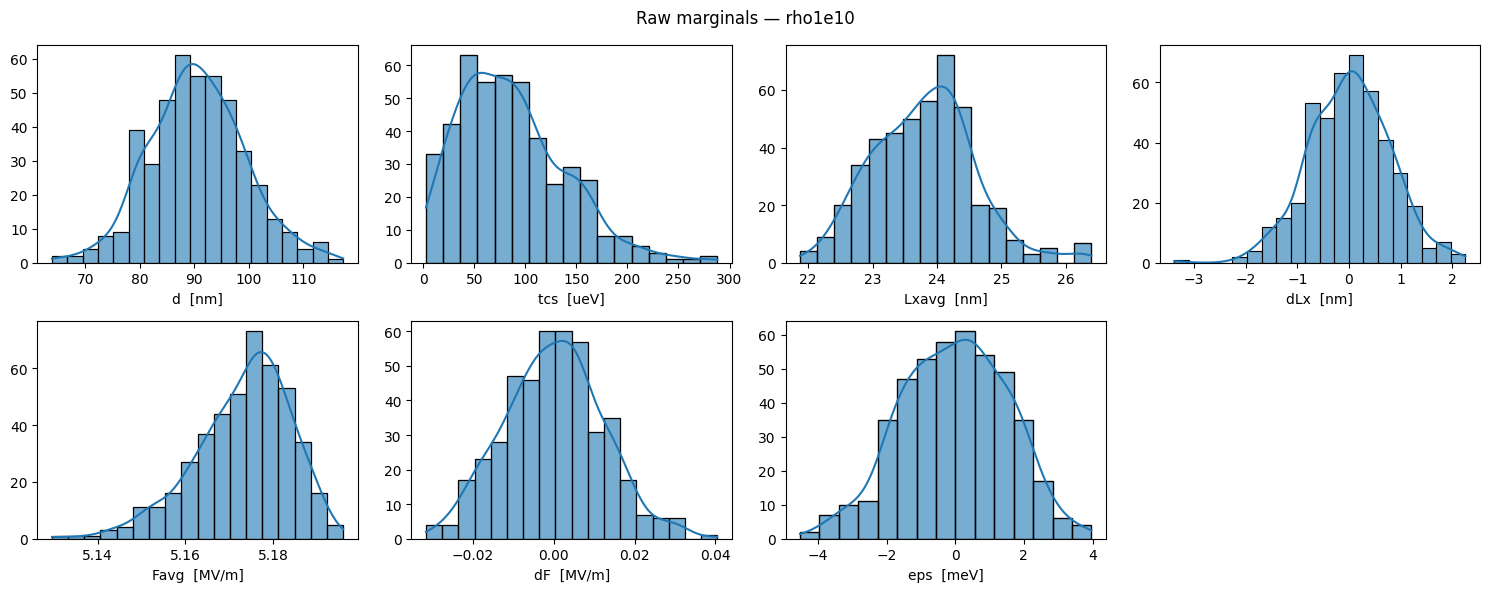

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, p in zip(axes.ravel(), PARAMS):
    sns.histplot(raw[p], ax=ax, kde=True, color="tab:blue", edgecolor="k", alpha=0.6)
    meta = ct.PARAMETERS[p]
    ax.set_xlabel(f"{p}  [{meta['unit']}]")
    ax.set_ylabel("")
for ax in axes.ravel()[len(PARAMS):]:
    ax.axis("off")
fig.suptitle(f"Raw marginals — {DATASET}")
fig.tight_layout()

## Correlations

The parameters are **not** independent: disorder that pushes the dots apart also
weakens the tunnel coupling and squeezes the confinement. That structure is
exactly what the generative models in notebook 2 have to reproduce — sampling
each parameter from its own histogram would throw it away.

Text(0.5, 1.0, 'Correlation matrix — rho1e10')

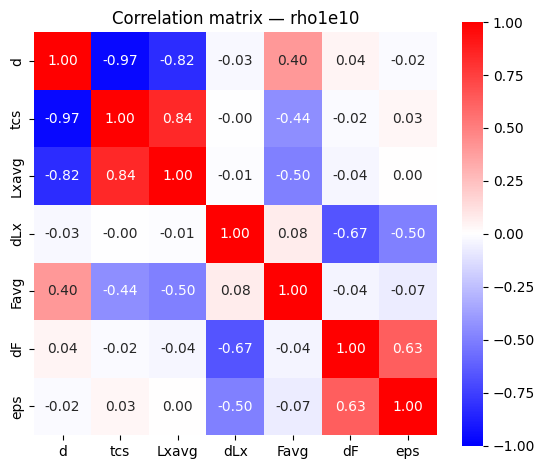

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(raw.corr(), cmap="bwr", vmin=-1, vmax=1, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title(f"Correlation matrix — {DATASET}")

## Comparing the two densities

Halving the charge density shrinks the spread of every parameter but leaves the
correlation structure largely intact.

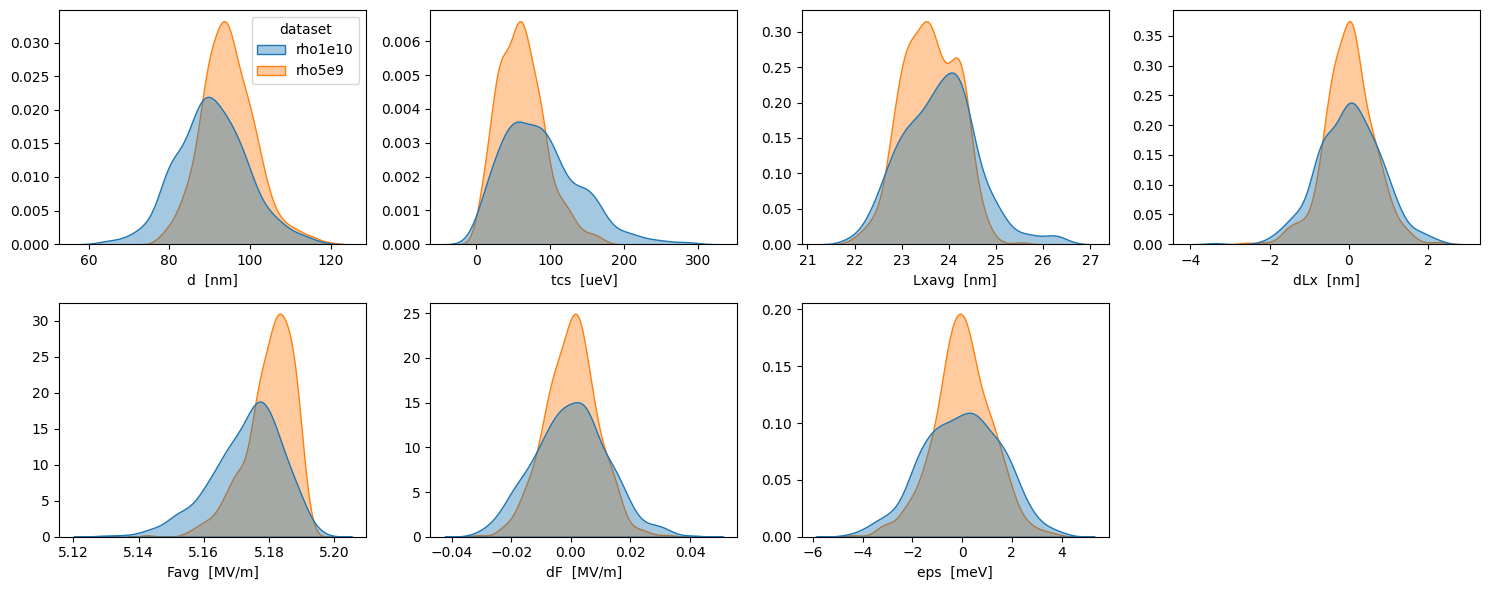

In [8]:
both = pd.concat([
    ct.load_dataset("rho1e10", PARAMS).assign(dataset="rho1e10"),
    ct.load_dataset("rho5e9", PARAMS).assign(dataset="rho5e9"),
])

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, p in zip(axes.ravel(), PARAMS):
    sns.kdeplot(data=both, x=p, hue="dataset", fill=True, alpha=0.4, ax=ax, legend=(p == PARAMS[0]))
    ax.set_xlabel(f"{p}  [{ct.PARAMETERS[p]['unit']}]")
    ax.set_ylabel("")
for ax in axes.ravel()[len(PARAMS):]:
    ax.axis("off")
fig.tight_layout()

Next: **`02_models_and_validation.ipynb`** — compress this ensemble into a
generative model and check that what comes out looks like what went in.